### **ANN with optuna and PCA**

- Import all the libraries required

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.decomposition import PCA
import optuna
from sklearn.metrics import accuracy_score, classification_report
import pickle

---

- Importing the training and testing dataset

In [2]:
X_train = pd.read_csv('../data/UCI-HAR Dataset/train/X_train.txt', sep = r'\s+', header = None)
y_train = pd.read_csv('../data/UCI-HAR Dataset/train/y_train.txt', sep = r'\s+', header = None)
X_test = pd.read_csv('../data/UCI-HAR Dataset/test/X_test.txt', sep = r'\s+', header = None)
y_test = pd.read_csv('../data/UCI-HAR Dataset/test/y_test.txt', sep = r'\s+', header = None)

---

- Setting the column names for features (has some duplicated column names as well so we have to also handle those)

In [3]:
# Dictionary to track how many times each label has appeared
label_counts = {}
columns_name = []
with open('../data/UCI-HAR Dataset/features.txt', 'r') as file:
    for line in file:
        line = line.rstrip("\n")
        parts = line.split(" ", 1)
        if len(parts) > 1:
            label = parts[1]

            if label in label_counts:
                label_counts[label] += 1
                unique_label = f"{label}_{label_counts[label]}"
            else:
                label_counts[label] = 0
                unique_label = label
            
            columns_name.append(unique_label)

X_train.columns = columns_name
X_test.columns = columns_name
y_train[0] = y_train[0] - 1
y_test[0] = y_test[0] - 1


class_names = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS',
               'SITTING', 'STANDING', 'LAYING']

In [4]:
X_train.sample(5)

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
1250,0.269674,0.010907,-0.074949,-0.336640,0.146250,-0.445571,-0.410055,0.152956,-0.445406,-0.158372,...,0.214963,0.077204,-0.322109,0.143221,-0.106539,0.527231,-0.847273,-0.804775,0.229686,-0.013299
2897,0.274292,-0.018835,-0.109409,-0.997304,-0.993624,-0.992330,-0.997600,-0.993056,-0.991099,-0.941284,...,0.212946,-0.506440,-0.834819,0.215963,-0.133353,0.516665,0.642485,-0.670948,0.230467,0.208524
3481,0.276915,-0.009242,-0.119937,-0.997484,-0.978983,-0.968226,-0.997611,-0.977205,-0.964276,-0.939509,...,0.630176,-0.738435,-0.957820,0.029279,0.053845,0.416160,-0.366803,-0.843634,0.176914,0.095226
4496,0.452692,-0.040913,-0.169488,0.469275,0.188400,-0.314750,0.463658,0.176654,-0.299852,0.564919,...,0.414001,-0.545794,-0.837422,-0.604205,-0.895028,0.940740,0.224635,-0.779377,0.226769,-0.066851
5676,0.277646,-0.011806,-0.100328,-0.996564,-0.972248,-0.976464,-0.996565,-0.972251,-0.976928,-0.943374,...,0.180809,-0.436570,-0.822592,0.025468,-0.022118,-0.362214,-0.235848,-0.873367,0.172610,-0.030471


In [5]:
y_train.head(5)

,0
0,4
1,4
2,4
3,4
4,4


---

- Performing PCA

In [6]:
pca = PCA(n_components = 0.95)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [7]:
X_train_pca.shape

(7352, 67)

---

- Creating a CustomDataset class and DataLoader objects with a batch size of 32

In [8]:
class CustomDataset(Dataset):

    def __init__(self, features, labels):

        self.features = torch.tensor(features, dtype = torch.float32)
        self.labels = torch.tensor(labels, dtype = torch.long)
    
    def __len__(self):

        return len(self.features)
    
    def __getitem__(self, index):

        return self.features[index], self.labels[index]

In [9]:
train_dataset = CustomDataset(X_train_pca, y_train.squeeze())
test_dataset = CustomDataset(X_test_pca, y_test.squeeze())

In [10]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True, drop_last = False)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False, drop_last = False)

---

- Making our objective function

In [11]:
class MyNN(nn.Module):

    def __init__(self, input_dim, output_dim, num_hidden_layer, neuron_per_layer, dropout_ratio):

        super().__init__()

        layers = []

        for i in range(num_hidden_layer):

            layers.append(nn.Linear(input_dim, neuron_per_layer))
            layers.append(nn.BatchNorm1d(neuron_per_layer))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_ratio))
            input_dim = neuron_per_layer
        
        layers.append(nn.Linear(neuron_per_layer, output_dim))

        #*layers unpacks a list as Sequential requires unpacked list
        self.model = nn.Sequential(*layers)

    def forward(self, x):

        return self.model(x)

In [12]:
def objective(trial):

    num_hidden_layer = trial.suggest_int("num_hidden_layers", 1, 5)
    neurons_per_layer = trial.suggest_int("neurons_per_layers", 8, 128, step = 8)
    dropout_ratio = trial.suggest_float("dropout_ratio", 0.1, 0.5)

    input_dim = X_train_pca.shape[1]
    output_dim = len(class_names)

    model = MyNN(input_dim, output_dim, num_hidden_layer, neurons_per_layer, dropout_ratio)

    epochs = 100
    learning_rate = 0.1

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(model.parameters(), lr = learning_rate, weight_decay = 1e-4)

    for epoch in range(epochs):

        for batch_features, batch_labels in train_loader:

            outputs = model(batch_features)

            loss = criterion(outputs, batch_labels)

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()
    
    model.eval()

    total = 0
    correct = 0

    with torch.no_grad():

        for batch_features, batch_labels in test_loader:

            outputs = model(batch_features)

            predicted = outputs.argmax(dim = 1)

            total += batch_labels.shape[0]

            correct += (predicted == batch_labels).sum().item()

        accuracy = correct/total

    return accuracy

---

- Creating our optuna object

In [13]:
study = optuna.create_study(direction = 'maximize')

study.optimize(objective, n_trials = 50)

[I 2026-06-20 12:55:36,872] A new study created in memory with name: no-name-cc70660c-47c9-493b-9397-ed7616085b0b
[I 2026-06-20 12:56:17,852] Trial 0 finished with value: 0.5310485239226331 and parameters: {'num_hidden_layers': 4, 'neurons_per_layers': 8, 'dropout_ratio': 0.46753877249701337}. Best is trial 0 with value: 0.5310485239226331.
[I 2026-06-20 12:56:48,834] Trial 1 finished with value: 0.9514760773668137 and parameters: {'num_hidden_layers': 2, 'neurons_per_layers': 120, 'dropout_ratio': 0.12716781747691397}. Best is trial 1 with value: 0.9514760773668137.
[I 2026-06-20 12:57:09,724] Trial 2 finished with value: 0.9351883271123176 and parameters: {'num_hidden_layers': 1, 'neurons_per_layers': 104, 'dropout_ratio': 0.4215471933027435}. Best is trial 1 with value: 0.9514760773668137.
[I 2026-06-20 12:57:37,587] Trial 3 finished with value: 0.9406175771971497 and parameters: {'num_hidden_layers': 2, 'neurons_per_layers': 24, 'dropout_ratio': 0.24765873055922258}. Best is trial 

In [14]:
study.best_value

0.9514760773668137

In [15]:
best_params = study.best_params
print(best_params)

{'num_hidden_layers': 2, 'neurons_per_layers': 120, 'dropout_ratio': 0.12716781747691397}


---

- The result of the model gave the best accuracy of 0.9521059782608695 with parameters, ***num_hidden_layers = 2***, ***neurons_per_layers = 120*** and ***dropout_ratio = 0.12716781747691397***.

Let's now train the model!

In [18]:
input_dim = X_train_pca.shape[1]
output_dim = len(class_names)

model = MyNN(input_dim, output_dim,
             num_hidden_layer = best_params['num_hidden_layers'],
             neuron_per_layer = best_params['neurons_per_layers'],
             dropout_ratio = best_params['dropout_ratio'])

epochs = 100
learning_rate = 0.1

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr = learning_rate, weight_decay = 1e-4)

for epoch in range(epochs):

    for batch_features, batch_labels in train_loader:

        outputs = model(batch_features)

        loss = criterion(outputs, batch_labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

---

- Now we test it with our test data

In [19]:
y_pred = []
y_test_all_batch = []

model.eval()

with torch.no_grad():

    for batch_features, batch_labels in test_loader:

        outputs = model(batch_features)

        predicted = outputs.argmax(dim = 1)

        y_pred.extend(predicted.cpu().numpy())
        y_test_all_batch.extend(batch_labels.cpu().numpy())
    
accuracy = accuracy_score(y_test_all_batch, y_pred)

c_report = classification_report(y_test_all_batch, y_pred, target_names = class_names)

print(f'Accuracy : {accuracy:.4f}\n')
print(f'Classification Report : \n{c_report}')

Accuracy : 0.9430

Classification Report : 
                    precision    recall  f1-score   support

           WALKING       0.97      0.93      0.95       496
  WALKING_UPSTAIRS       0.89      0.95      0.92       471
WALKING_DOWNSTAIRS       0.95      0.92      0.93       420
           SITTING       0.97      0.87      0.92       491
          STANDING       0.89      0.97      0.93       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.95      0.94      0.94      2947



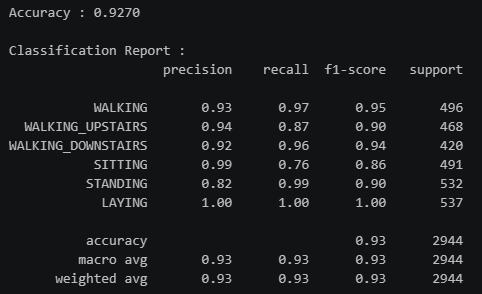

This classification report showed that most activities were identified accurately.

---

- Saving the models

In [20]:
with open("../models/pca.pkl", "wb") as file:
    pickle.dump(pca, file)

torch.save(
    model.state_dict(),
    "../models/ann_model.pth"
)

with open("../models/class_names.pkl", "wb") as file:
    pickle.dump(class_names, file)

with open("../models/best_params.pkl", "wb") as f:
    pickle.dump(study.best_params, f)

---